In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind # T-test for independent samples
from scipy.stats import shapiro # Shapiro-Wilk’s test for Normality
from scipy.stats import levene # Levene's test for Equality of Variance
from scipy.stats import f_oneway # One-way ANOVA
from scipy.stats import kruskal
from scipy.stats import chi2_contingency # Chi-square test of independence

In [ ]:
df=pd.read_csv("/content/sample_data/bike_sharing.csv")

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,01-01-2011 0.00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,01-01-2011 1.00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,01-01-2011 2.00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,01-01-2011 3.00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,01-01-2011 4.00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.describe(include="O")

,datetime
count,10886
unique,10886
top,19-12-2012 23.00
freq,1


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


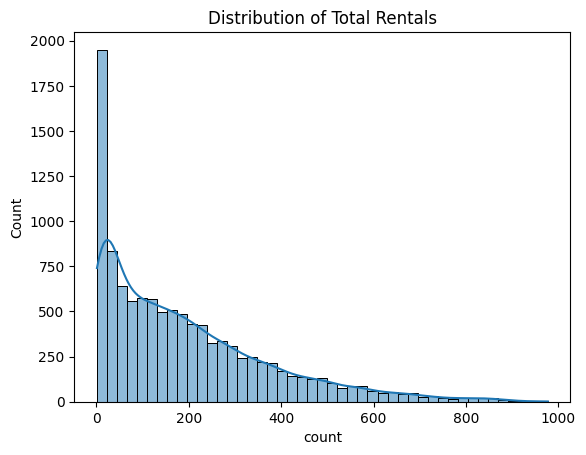

In [ ]:
sns.histplot(df['count'], kde=True)
plt.title("Distribution of Total Rentals")
plt.show()

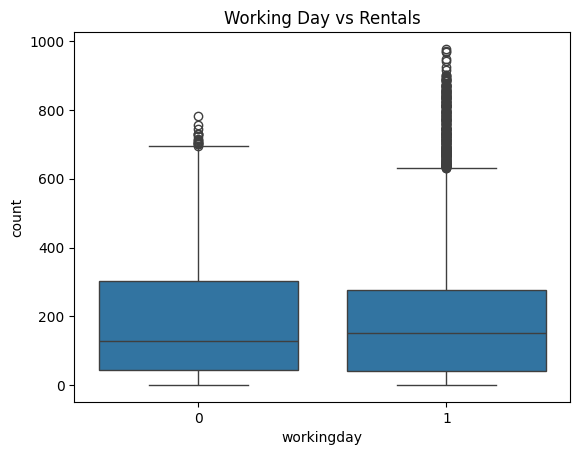

In [ ]:
sns.boxplot(x='workingday', y='count', data=df)
plt.title("Working Day vs Rentals")
plt.show()

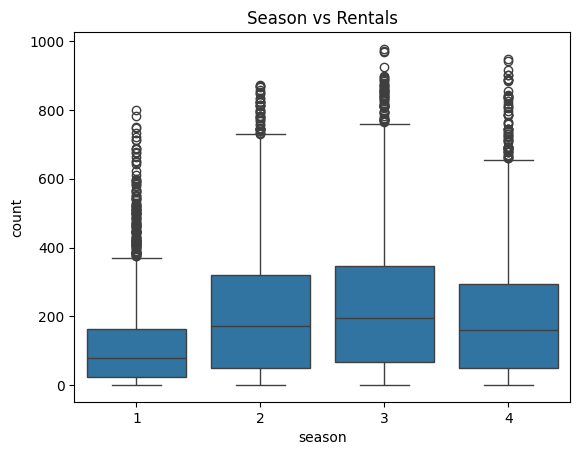

In [ ]:
sns.boxplot(x='season', y='count', data=df)
plt.title("Season vs Rentals")
plt.show()


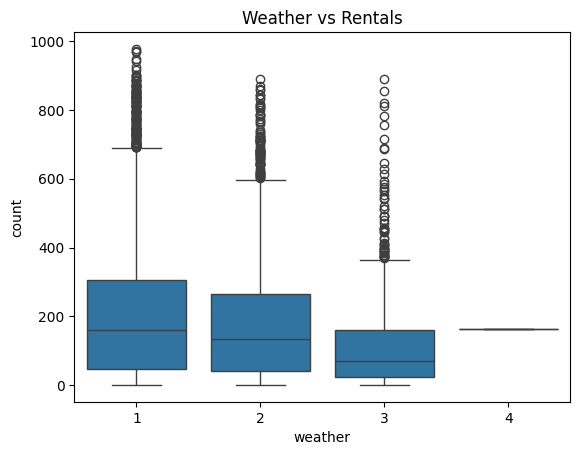

In [ ]:
sns.boxplot(x='weather', y='count', data=df)
plt.title("Weather vs Rentals")
plt.show()

In [ ]:
def dist_check(df,col_name):
  print("Unique values",df[col_name].unique())
  print("Value coounts", df[col_name].value_counts())

In [ ]:
col_list=["season","holiday","workingday","weather"]
for items in col_list:
  print(f"Column Name: {items}")
  dist_check(df,col_name=items)
  print("-------"*10)

Column Name: season
Unique values [1 2 3 4]
Value coounts season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
----------------------------------------------------------------------
Column Name: holiday
Unique values [0 1]
Value coounts holiday
0    10575
1      311
Name: count, dtype: int64
----------------------------------------------------------------------
Column Name: workingday
Unique values [0 1]
Value coounts workingday
1    7412
0    3474
Name: count, dtype: int64
----------------------------------------------------------------------
Column Name: weather
Unique values [1 2 3 4]
Value coounts weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
----------------------------------------------------------------------


In [ ]:
df_only_num=df.select_dtypes(include=["float","int"])

<Axes: >

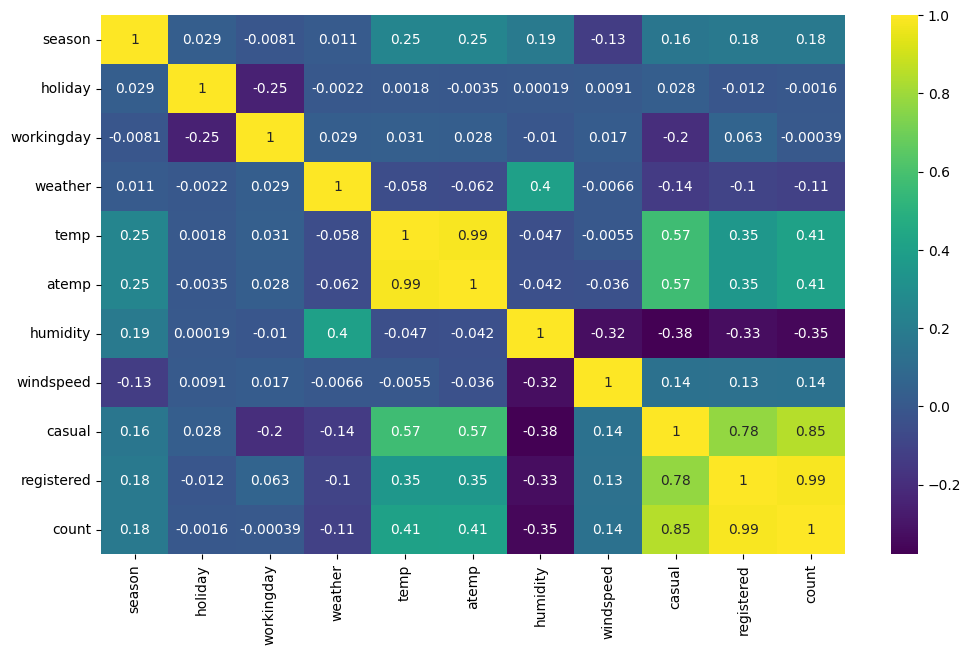

In [ ]:
plt.figure(figsize=(12, 7)) ## This define my canvas size.
sns.heatmap(df_only_num.corr(method='spearman'),
            annot=True, cmap='viridis')

In [ ]:
dfn=df.drop(columns=['casual','registered','atemp'])

In [ ]:
dfn.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,count
0,01-01-2011 0.00,1,0,0,1,9.84,81,0.0,16
1,01-01-2011 1.00,1,0,0,1,9.02,80,0.0,40
2,01-01-2011 2.00,1,0,0,1,9.02,80,0.0,32
3,01-01-2011 3.00,1,0,0,1,9.84,75,0.0,13
4,01-01-2011 4.00,1,0,0,1,9.84,75,0.0,1


/tmp/ipykernel_7501/2053929371.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dfn['count'],bins=10)


<Axes: xlabel='count', ylabel='Density'>

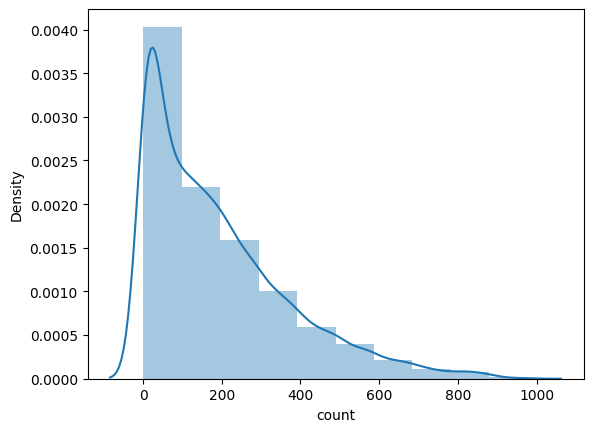

In [ ]:
sns.distplot(dfn['count'],bins=10)

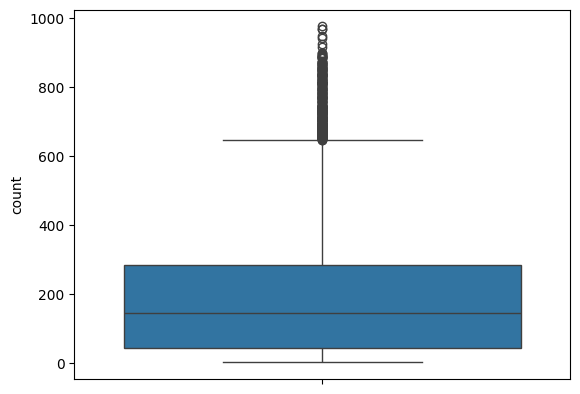

In [ ]:
sns.boxplot(y=dfn['count'])
plt.show()

/tmp/ipykernel_7501/2822955991.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(dfn['count']),bins=10)


<Axes: xlabel='count', ylabel='Density'>

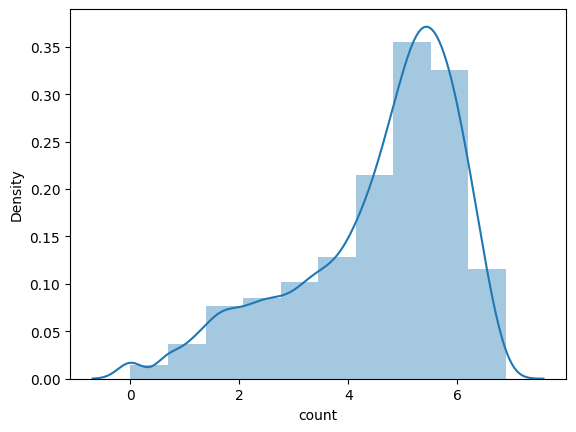

In [ ]:
sns.distplot(np.log(dfn['count']),bins=10)

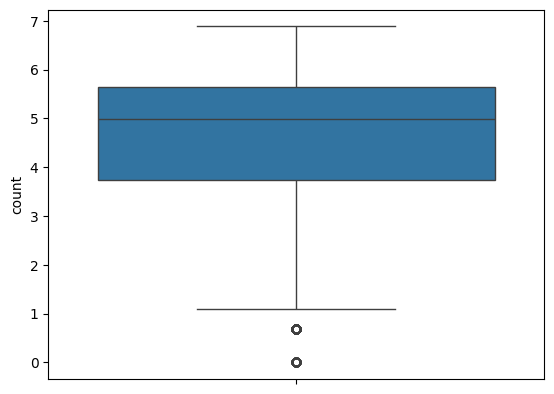

In [ ]:
sns.boxplot(y=np.log(dfn['count']))
plt.show()

/tmp/ipykernel_7501/1267814950.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(dfn['count']),bins=3)


<Axes: xlabel='count', ylabel='Density'>

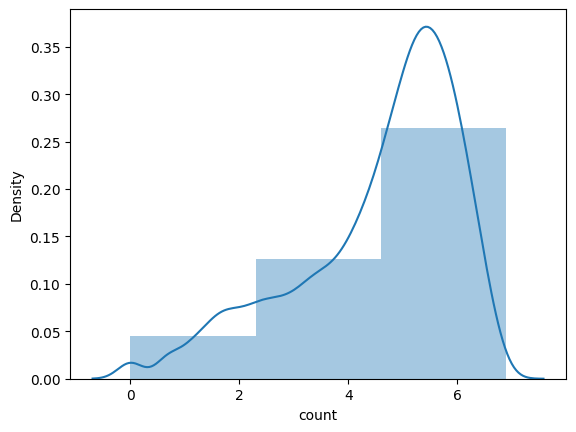

In [ ]:
sns.distplot(np.log(dfn['count']),bins=3)

In [ ]:
working = df[df['workingday'] == 1]['count']
non_working = df[df['workingday'] == 0]['count']

In [ ]:
print(shapiro(working.sample(500)))
print(shapiro(non_working.sample(500)))

ShapiroResult(statistic=np.float64(0.8775435155307115), pvalue=np.float64(1.9786364287458577e-19))
ShapiroResult(statistic=np.float64(0.8899810488264974), pvalue=np.float64(1.9667977677648904e-18))


In [ ]:
levene(working, non_working)

LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))

In [ ]:
ttest_ind(working, non_working, equal_var=False)

TtestResult(statistic=np.float64(1.2362580418223226), pvalue=np.float64(0.21640312280695098), df=np.float64(7176.288413844308))

Is there any significant difference between the no. of bike rides on weekdays and weekends?
H0: The demand of bikes on weekdays is greater or similar to the demand of bikes on weekend.
Ha: The demand of bikes on weekdays is less than the demand of bikes on weekend.
Let μ1 and μ2 be the average no. of bikes rented on weekdays and weekends respectively.
Mathematically, the above formulated hypothesis can be written as:
H0:μ1>=μ2
Ha:μ1<μ2


In [ ]:
dfn.groupby('workingday')['count'].size()

,count
workingday,
0,3474
1,7412


In [ ]:
weekday=dfn[dfn['workingday']==1]['count'].sample(3000)
weekend=dfn[dfn['workingday']==0]['count'].sample(3000)

In [ ]:
round(weekday.std(), 2)

184.78

In [ ]:
round(weekend.std(),2)

173.3

In [ ]:
alpha=0.05

In [ ]:
def result(p_value, alpha):
  if p_value < alpha:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
  else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

In [ ]:
test_stat,p_value=ttest_ind(weekday,weekend,equal_var=False,alternative="less")

In [ ]:
p_value

np.float64(0.7621432537519165)

In [ ]:
result(p_value,alpha)

As the p-value 0.7621432537519165 is greater than the level of significance, we fail to reject the null hypothesis.


Is the demand of bicycles on rent same for different weather conditions?

In [ ]:
dfn.groupby('weather')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


Step 1: Define the null and alternate hypothesis
H0:  The average no. of bike rides in different weather conditions are equal.

Ha:  The average no. of bike rides in different weather conditions are not equal.

Let  μ1  and  μ2  be the average no. of bikes rented on weekdays and weekends respectively.

In [ ]:
dfn=dfn[~(dfn['weather']==4)]

In [ ]:
w1=dfn[dfn['weather']==1]['count'].sample(750)
w2=dfn[dfn['weather']==2]['count'].sample(750)
w3=dfn[dfn['weather']==3]['count'].sample(750)
#w4=dfn[dfn['weather']==4]['count'].sample(750)
#

Shapiro test

In [ ]:
## Ho : Normal Ha: Npt normal

w,p_value=shapiro(dfn['count'].sample(5000))
result(p_value,alpha)

As the p-value 3.0209177693448863e-53 is less than the level of significance, we reject the null hypothesis.


In [ ]:
stat,p_value=kruskal(w1,w2,w3)
result(p_value,alpha)

As the p-value 3.5073601370338214e-26 is less than the level of significance, we reject the null hypothesis.


Are the weather conditions significantly different during different seasons?
Step 1: Define the null and alternate hypothesis
H0:  Weather conditions are independent of the season.

Ha:  Weather condition depends on the ongoing season.

In [ ]:
dict1={1:'Sunny',
      2:'Cloudy',
      3:'Rainy'}

dfn["weather_enc"]=dfn["weather"].map(dict1)

In [ ]:
dict2={1:'Summer',
      2:'Monsoon',
      3:'Winter',
      4:'Autumn'}

dfn["season_enc"]=dfn["season"].map(dict2)

In [ ]:
contingency=pd.crosstab(dfn.season_enc,dfn.weather_enc)

In [ ]:
contingency

weather_enc,Cloudy,Rainy,Sunny
season_enc,,,
Autumn,807,225,1702
Monsoon,708,224,1801
Summer,715,211,1759
Winter,604,199,1930


In [ ]:
chi2, pval, dof, exp_freq = chi2_contingency(contingency, correction=False)
print('Chi-square Statistic: {} \n P-value: {} \n Degree of Freedom: {} \n Expected Frequencies: {}'.format(chi2, pval, dof, exp_freq))

Chi-square Statistic: 46.10145731073249 
 P-value: 2.8260014509929343e-08 
 Degree of Freedom: 6 
 Expected Frequencies: [[ 711.81956821  215.75617823 1806.42425356]
 [ 711.55920992  215.67726229 1805.76352779]
 [ 699.06201194  211.8892972  1774.04869086]
 [ 711.55920992  215.67726229 1805.76352779]]


In [ ]:
result(pval,alpha)

As the p-value 2.8260014509929343e-08 is less than the level of significance, we reject the null hypothesis.
